In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ResNet3D, ResNetBlock3D, GraphConvolution, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph, pm, diagnostics

print(jax.devices("gpu"))
print(jax.default_backend())

[cuda(id=0)]
gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0
dt0 = 0.02

# CAMELS

In [4]:
# i_snapshots=range(1, 33+8, 8)

hydro_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    # i_snapshots=i_snapshots,
)

cosmo = hydro_dict["cosmo"]
scales = hydro_dict["scales"]

dm_poss = hydro_dict["dm_poss"]
dm_vels = hydro_dict["dm_vels"]

gas_poss = hydro_dict["gas_poss"]
gas_vels = hydro_dict["gas_vels"]

Loaded /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5


In [5]:
# i_snapshots = np.arange(10, 18)
# i_snapshots = np.arange(-8, 0)
i_snapshots = np.arange(0, 8)
# i_snapshots=range(1, 33+4, 4),

scales = scales[i_snapshots]

dm_poss = dm_poss[i_snapshots]
dm_vels = dm_vels[i_snapshots]

gas_poss = gas_poss[i_snapshots]
gas_vels = gas_vels[i_snapshots]

In [6]:
# @nnx.jit(static_argnames=("loss_fn",))
@nnx.jit
def train_step(pressure_model, fourier_model, fourier_optimizer):
    def loss_fn_wrapper(fourier_model):
        return particle_loss_fn(pressure_model, fourier_model)

    loss, grads = nnx.value_and_grad(loss_fn_wrapper)(fourier_model)
    fourier_optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)

    return loss, grad_norm

In [7]:
def solve_ode_diffrax(pressure_model, fourier_model):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            pressure_model=pressure_model,
            fourier_model=fourier_model,
        )
    )
    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=dt0,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
    )

    res = res.ys

    return res

In [8]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

# loss

### CAMELS ground truth

In [9]:
# per-particle reference
# ref_poss = jnp.stack(dm_poss, axis=0)
# ref_vels = jnp.stack(dm_vels, axis=0)

ref_poss = jnp.stack(gas_poss, axis=0)
ref_vels = jnp.stack(gas_vels, axis=0)


# field-level reference
ref_rhos = vcic_paint(jnp.zeros(mesh_shape), ref_poss)

# power spectrum reference
_, ref_cls = vpower_spectrum(ref_rhos)

# vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [10]:
# gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)
# dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)

# # per-particle reference
# ref_gas_pos = jnp.stack(gas_poss, axis=0)
# ref_gas_vel = jnp.stack(gas_vels, axis=0)

# # field-level reference
# n_rho_dm = vcic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"], 1)

# h_rho_dm = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"], dm_mass)
# h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"], gas_mass)

# # power spectrum reference
# _, n_cl_dm = vpower_spectrum(n_rho_dm)

# _, h_cl_dm = vpower_spectrum(h_rho_dm)
# _, h_cl_gas = vpower_spectrum(h_rho_gas)

# # vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

### particle-level

In [11]:
def particle_loss_fn(pressure_model, fourier_model, eps=1e-8):
    res = solve_ode_diffrax(pressure_model, fourier_model)
    # dark matter
    # poss = res[0]
    # vels = res[1]

    # gas
    poss = res[2]
    vels = res[3]

    delta_poss = ((poss - ref_poss + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_poss**2, axis=-1)
    pos_loss = jnp.mean(pos_loss)
    
    res_rhos = vcic_paint(jnp.zeros(mesh_shape), poss)
    kbins, res_cls = vpower_spectrum(res_rhos)

    k = kbins[0]
    k_min, k_cutoff = k[0], k[int(0.2*len(k))]
    k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

    cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)
    cl_loss = jnp.mean(cl_loss)

    return pos_loss + 0.1 * cl_loss


In [12]:
# solve_ode_diffrax(pressure_model, fourier_model)
# particle_loss_fn(pressure_model, fourier_model)
# train_step(pressure_model, fourier_model, fourier_optimizer)

### field-level

In [13]:
def field_loss_fn(model, architecture):
    pass

# architecture

In [14]:
checkpoint_file = "/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/sims/checkpoints/mlp_sim_v4_full.jx"

model = MLP(
    d_in=5,
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="batch",
)

checkpointer = ocp.StandardCheckpointer()

abstract_model = nnx.eval_shape(lambda: model)
graphdef, abstract_params = nnx.split(abstract_model)

params = checkpointer.restore(checkpoint_file, abstract_params)
pressure_model = nnx.merge(graphdef, params)

/cluster/home/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1386: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [15]:
fourier_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))

# training

In [16]:
total_steps = 1000
learning_rate = 1e-3
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

fourier_optimizer = nnx.Optimizer(
    fourier_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grad_norms = []
# loss_fn = particle_loss_fn
# loss_fn = lambda model: field_loss_fn(model, architecture)

  0%|          | 0/1000 [00:00<?, ?it/s]

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


2025-04-25 20:58:57.090915: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %negate.4 = f32[8,262144,3]{2,1,0} negate(f32[8,262144,3]{2,1,0} %constant.212)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-04-25 20:59:00.540741: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 4.449939086s
Constant folding an instruction is taking > 1s:

  %negate.4 = f32[8,262144,3]{2,1,0} negate(f32[8,262144,3]{2,1,0} %constant.212)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guar

[None]

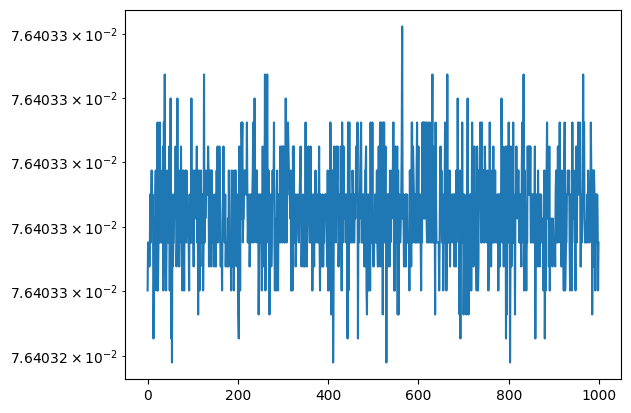

In [17]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss, grad_norm = train_step(pressure_model, fourier_model, fourier_optimizer)
    
    losses.append(float(loss))
    grad_norms.append(float(grad_norm))
    pbar.set_description(f"Loss: {loss:.4f}, Grad norm: {grad_norm:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

### checkpointing

In [18]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim_new_2.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [19]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [20]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 8/8 [00:04<00:00,  1.62it/s]


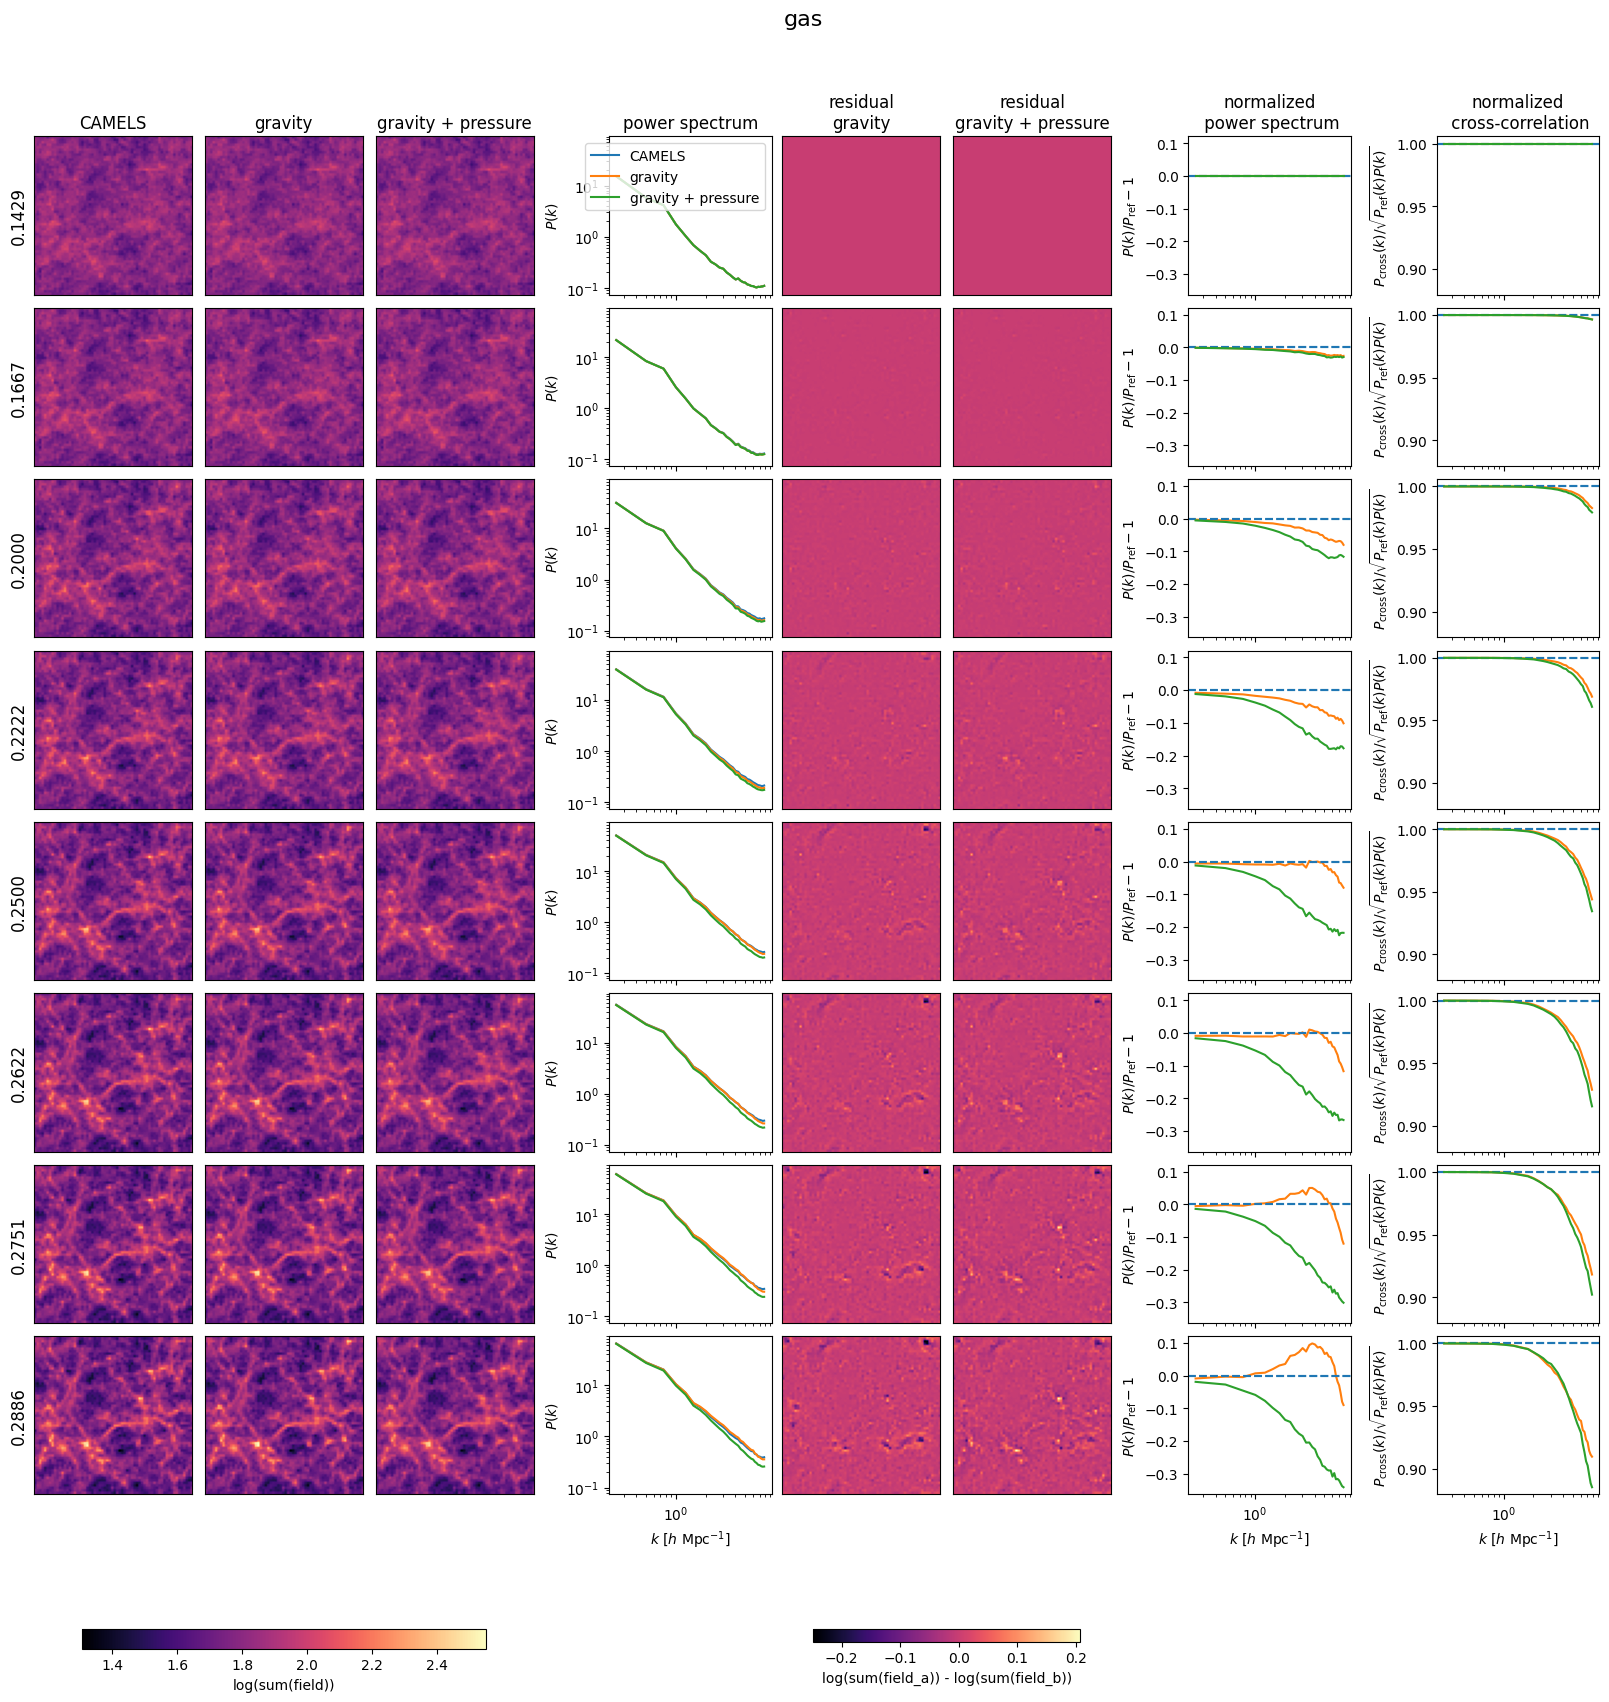

In [21]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)
og_res = diffeqsolve(
    terms=ODETerm(og_ode),
    solver=LeapfrogMidpoint(),
    t0=scales[0],
    t1=scales[-1],
    dt0=dt0,
    y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
    saveat=SaveAt(ts=scales),
    max_steps=100,
    stepsize_controller=ConstantStepSize(),
)
og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

nn_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim,
    cosmo,
    pressure_model=pressure_model,
    fourier_model=fourier_model,
    # gas_architecture=architecture,
)
nn_res = diffeqsolve(
    terms=ODETerm(nn_ode),
    solver=LeapfrogMidpoint(),
    t0=scales[0],
    t1=scales[-1],
    dt0=dt0,
    y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
    saveat=SaveAt(ts=scales),
    max_steps=100,
    stepsize_controller=ConstantStepSize(),
)
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys

with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        [mesh_per_dim] * 3,
        scales,
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0),
        title="gas",
        col_titles=["CAMELS", "gravity", "gravity + pressure"],
        include_pk=True,
        include_reference=True,
    )


In [22]:
stop

NameError: name 'stop' is not defined

In [ ]:
vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

In [ ]:
compare_sims(vali_dict)